# Model Interpretation

## Objective
 
 The objective of this notebook is to understand which customer features have the greatest influence on churn prediction. Feature importance from the trained Random Forest Model will be used to identify the most important predictors.

In [1]:
# Import pandas

import pandas as pd

# Import joblib to load the trained model

import joblib

# Import matplotlib for visualization

import matplotlib.pyplot as plt


In [3]:
# Load the encoded dataset

df=pd.read_csv("../data/processed/encoded_telco_churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_0-12,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-72,MonthlyChargeCategory_High,MonthlyChargeCategory_Low,MonthlyChargeCategory_Medium
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,1,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,1,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,1,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,0,0,1,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,1,0,1,0,0,0,1,0,0


In [5]:
# Seperate the features from the target variable

x= df.drop("Churn", axis=1)
y=df["Churn"]

In [6]:
# Load the tuned Random Forest Model

model= joblib.load("../models/tuned_random_forest.pkl")

In [8]:
# Display no of features used by the model

print("Numbers of features used:", x.shape[1])
print(model)

Numbers of features used: 49
RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)


## Feature Importance

Feature Importance helps identify which customer attributes contribute most to the Random Forest Model predictions. This 
can provide useful insights into the factors associated with customer churn.

In [9]:
# Extract feature importance scores from the Random Forest Model

imp= model.feature_importances_

In [13]:
# Create a dataframe with feature names and their important scores

feature_importance = pd.DataFrame({"feature": x.columns,"Importance":imp})

In [16]:
# Sort features from most important to least important

feature_importance = feature_importance.sort_values( by="Importance",ascending=False)
feature_importance.head(10)

,feature,Importance
4,tenure,0.116008
8,TotalCharges,0.098003
7,MonthlyCharges,0.086328
35,Contract_Month-to-month,0.076547
17,OnlineSecurity_No,0.060464
26,TechSupport_No,0.047861
42,TenureGroup_0-12,0.043576
15,InternetService_Fiber optic,0.042242
40,PaymentMethod_Electronic check,0.034015
10,LongTermCustomer,0.032380


## Visualize Feature Importance

The most important features are visualised to make the models results easier to interpret.

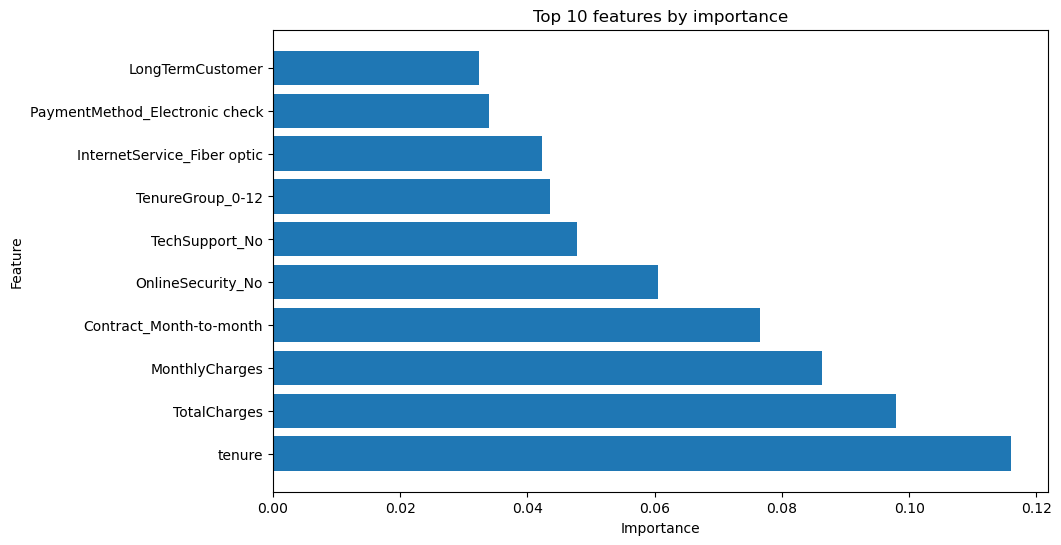

In [23]:
# Select the top 10 important features

top_features= feature_importance.head(10)
plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["Importance"]
)

# Add labels and title

plt.title("Top 10 features by importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

#Display the most feature at the top

plt.gca().invert_yaxis
plt.show()